In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

In [3]:
import tensorflow as tf
import keras
from keras import preprocessing
from keras.models import load_model
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras import layers
from keras.models import Sequential
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.applications import MobileNetV2

## Data Prep

In [4]:
# local imports
def download_dataset(path:str, seed:int=40):
    import kagglehub
    import shutil

    if 'COLAB_GPU' in os.environ: # if working is google colab
        print('Working in COLAB')
        # Download latest version
        path = kagglehub.dataset_download("alessiocorrado99/animals10")

        dataset_path = path
        raw_img_candidate = os.path.join(path, 'raw-img')
        if os.path.isdir(raw_img_candidate):
            dataset_path = raw_img_candidate
    else:
        path = kagglehub.dataset_download("alessiocorrado99/animals10")
        destination = os.path.join(os.path.curdir,r'raw-img\\raw-img')
        os.makedirs(destination, exist_ok=True)

        for item in os.listdir(path):
            src = os.path.join(path, item)
            dst = os.path.join(destination, item)
            shutil.move(src, dst)
        shutil.rmtree(path, ignore_errors=True)
        print('Working locally')
        dataset_path = destination

    print("Path to dataset files:", dataset_path)
    dataset = keras.utils.image_dataset_from_directory(
        dataset_path, label_mode='int', labels='inferred',
        image_size=(64, 64), shuffle=False, seed=seed,
        batch_size=32, color_mode='rgb',
    )

    return dataset, dataset_path

# Dataset
local_data_dir = os.path.join(os.getcwd(), r'raw-img\\raw-img')
if os.path.isdir(local_data_dir):
    print('Using local dataset folder:', local_data_dir)
    data_dir = local_data_dir
    df = None
else:
    df, data_dir = download_dataset(path=os.getcwd())


Using local dataset folder: c:\Users\paudu\Desktop\coding\classes\homework\February\Project\raw-img\\raw-img


In [5]:
translate = {"ragno":"spider" ,"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep", "scoiattolo": "squirrel", "dog": "cane", "cavallo": "horse", "elephant" : "elefante", "butterfly": "farfalla", "chicken": "gallina", "cat": "gatto", "cow": "mucca", "spider": "ragno", "squirrel": "scoiattolo"}

filepaths = []
labels = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            filepaths.append(os.path.join(class_path, file))
            labels.append(translate[label])

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

df

,filepath,label
0,c:\Users\paudu\Desktop\coding\classes\homework...,dog
1,c:\Users\paudu\Desktop\coding\classes\homework...,dog
2,c:\Users\paudu\Desktop\coding\classes\homework...,dog
3,c:\Users\paudu\Desktop\coding\classes\homework...,dog
4,c:\Users\paudu\Desktop\coding\classes\homework...,dog
...,...,...
26174,c:\Users\paudu\Desktop\coding\classes\homework...,squirrel
26175,c:\Users\paudu\Desktop\coding\classes\homework...,squirrel
26176,c:\Users\paudu\Desktop\coding\classes\homework...,squirrel
26177,c:\Users\paudu\Desktop\coding\classes\homework...,squirrel


## Data Loading

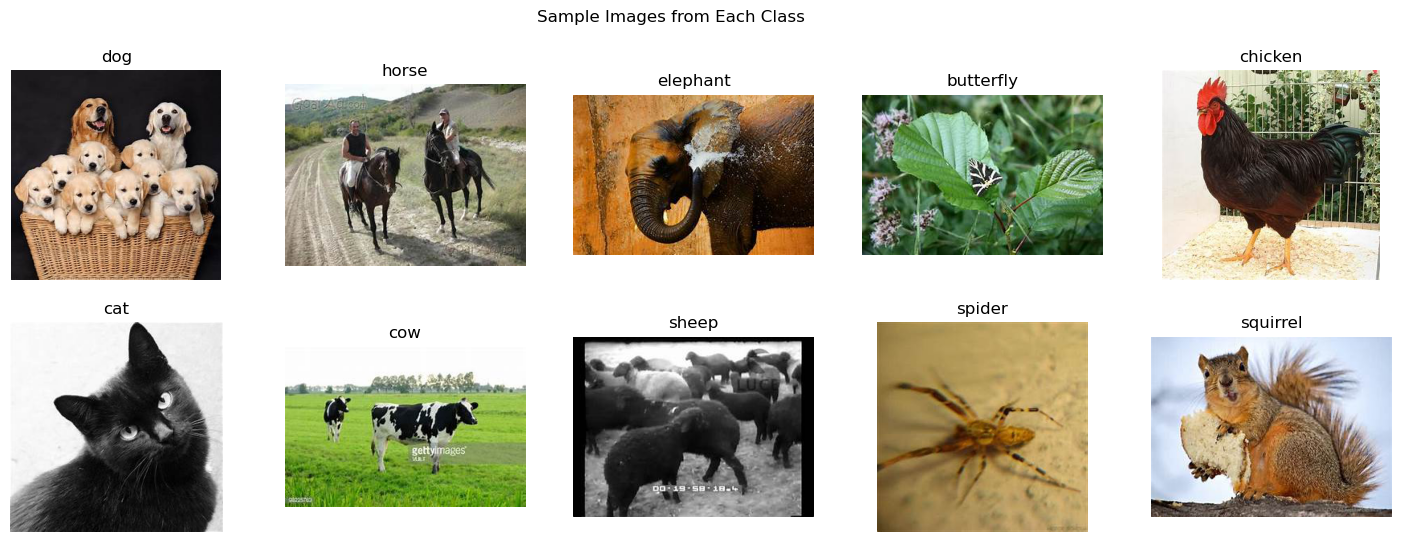

In [6]:
figure, axes = plt.subplots(2, 5, figsize=(18, 6))
figure.suptitle("Sample Images from Each Class", fontsize=12)

images = []
for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    class_images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    if not class_images:
        continue
    images.append(os.path.join(class_path, class_images[np.random.randint(0, len(class_images))]))

for i, img_path in enumerate(images[:20]):
    img = Image.open(img_path)
    row, col = divmod(i, 5)
    axes[row, col].imshow(img)
    axes[row, col].set_title(
        f"{translate[os.path.basename(os.path.dirname(img_path))]}"
    )
    axes[row, col].axis('off')

## Data preprocessing

In [7]:
from sklearn.model_selection import train_test_split

# 70% train
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 18325
Val: 3927
Test: 3927


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


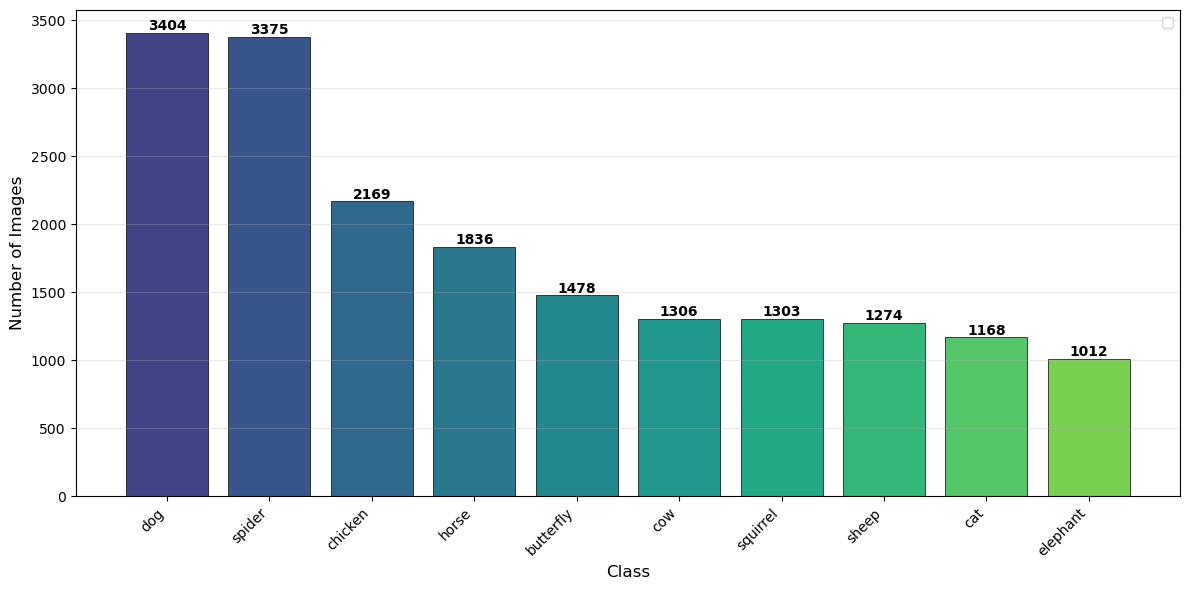


Total training images: 18325
Min: elephant (1012), Max: dog (3404)
Imbalance ratio: 3.36x


In [10]:
counts = train_df["label"].value_counts().values
names = train_df["label"].value_counts().index

# Color gradient
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))

plt.figure(figsize=(12, 6))
bars = plt.bar(names, counts, color=colors, edgecolor='black', linewidth=0.5)

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal training images: {sum(counts)}")
print(f"Min: {names[-1]} ({counts[-1]}), Max: {names[0]} ({counts[0]})")
print(f"Imbalance ratio: {max(counts)/min(counts):.2f}x")

## split data

In [19]:
INPUT_SHAPE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 18325 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.


## Modeling

In [20]:
# checkpoint saves the best model based on validation accuracy during training
os.makedirs('./models', exist_ok=True)
checkpoint_path = './models/best_model_stage1.keras'

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
)

# early stopping stop training if val_loss does not improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-7
)


In [21]:
classes = np.unique(train_generator.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
class_weights_dict

{0: np.float64(1.239851150202977),
 1: np.float64(1.5689212328767124),
 2: np.float64(0.8448593822037805),
 3: np.float64(1.4031393568147015),
 4: np.float64(0.538337250293772),
 5: np.float64(1.8107707509881423),
 6: np.float64(0.9980936819172114),
 7: np.float64(1.4383830455259026),
 8: np.float64(0.542962962962963),
 9: np.float64(1.406369915579432)}

In [22]:
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = Sequential([
    base_model,
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,106,570 (11.85 MB)

 Trainable params: 2,053,770 (7.83 MB)

 Non-trainable params: 1,052,800 (4.02 MB)

## Training

In [ ]:
MODEL_PATH = './models/model.keras'
FIXED_MODEL_PATH = './models/model_fixed.keras'
HISTORY_PATH = './histories/model-history.npy'
os.makedirs('./models', exist_ok=True)
os.makedirs('./histories', exist_ok=True)

retrain = 'y'
if os.path.exists(MODEL_PATH):
    retrain = input("Model already exists. Would you like to retrain? (y/n): ").strip().lower()

if retrain == 'y':
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        class_weight=class_weights_dict,
        callbacks=[checkpoint, early_stop, reduce_lr]
    )
    model_history = history.history
    model.save(MODEL_PATH)
    np.save(HISTORY_PATH, model_history)
else:
    def _build_model_for_legacy_weights():
        base_model = MobileNetV2(weights=None, include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        rebuilt_model = Sequential([
            base_model,
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(10, activation='softmax')
        ])
        return rebuilt_model

    preferred_path = FIXED_MODEL_PATH if os.path.exists(FIXED_MODEL_PATH) else MODEL_PATH
    try:
        model = load_model(preferred_path, compile=False)
        print(f'Loaded model from: {preferred_path}')
    except Exception as e:
        print(f'Direct load failed ({e.__class__.__name__}). Converting legacy model to current format...')
        import tempfile
        from zipfile import ZipFile

        model = _build_model_for_legacy_weights()
        with tempfile.TemporaryDirectory() as tmpdir:
            with ZipFile(MODEL_PATH) as zf:
                zf.extract('model.weights.h5', path=tmpdir)
            model.load_weights(os.path.join(tmpdir, 'model.weights.h5'))

        model.save(FIXED_MODEL_PATH)
        print(f'Saved converted model to: {FIXED_MODEL_PATH}')

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    if os.path.exists(HISTORY_PATH):
        model_history = np.load(HISTORY_PATH, allow_pickle=True).item()
    else:
        raise FileNotFoundError(f"History file not found: {HISTORY_PATH}")

Model already exists. Would you like to retrain? (y/n): n
Loaded model from: ./models/model.keras


In [24]:
# Optional: reload history from disk if this notebook is restarted.
if 'model_history' not in locals():
    model_history = np.load('./histories/model-history.npy', allow_pickle=True).item()


## Evaluation and Visualization

In [25]:
loss, accuracy = model.evaluate(train_generator)
print("Evaluation on data train: ")
print(f"accuracy: {accuracy*100:.2f}")
print(f"loss: {loss}")

loss, accuracy = model.evaluate(test_generator)
print("Evaluation on data test: ")
print(f"accuracy: {accuracy*100:.2f}")
print(f"loss: {loss}")

loss, accuracy = model.evaluate(val_generator)
print("Evaluation on data validation: ")
print(f"accuracy: {accuracy*100:.2f}")
print(f"loss: {loss}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


573/573 ━━━━━━━━━━━━━━━━━━━━ 363s 606ms/step - accuracy: 0.9955 - loss: 0.0142
Evaluation on data train: 
accuracy: 99.44
loss: 0.016955096274614334
123/123 ━━━━━━━━━━━━━━━━━━━━ 37s 304ms/step - accuracy: 0.9588 - loss: 0.1630
Evaluation on data test: 
accuracy: 95.95
loss: 0.17377769947052002
123/123 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.9621 - loss: 0.1566
Evaluation on data validation: 
accuracy: 96.03
loss: 0.1734694391489029


123/123 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step
              precision    recall  f1-score   support

   butterfly       0.96      0.99      0.97       317
         cat       0.93      0.95      0.94       250
     chicken       0.97      0.98      0.98       465
         cow       0.91      0.92      0.91       280
         dog       0.98      0.94      0.96       729
    elephant       0.92      0.99      0.95       217
       horse       0.95      0.95      0.95       394
       sheep       0.93      0.93      0.93       273
      spider       0.99      0.98      0.98       723
    squirrel       0.96      0.98      0.97       279

    accuracy                           0.96      3927
   macro avg       0.95      0.96      0.95      3927
weighted avg       0.96      0.96      0.96      3927



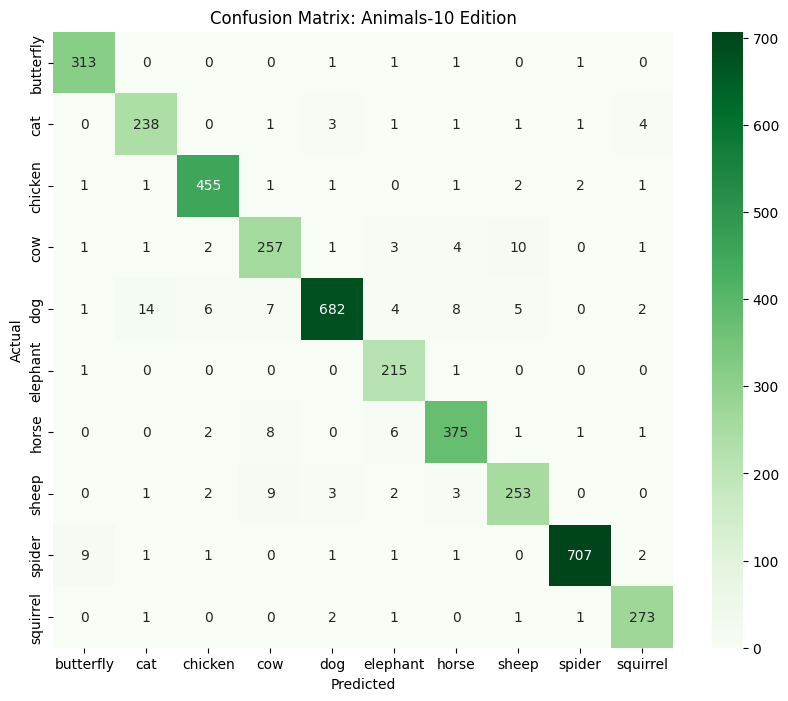

In [ ]:
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

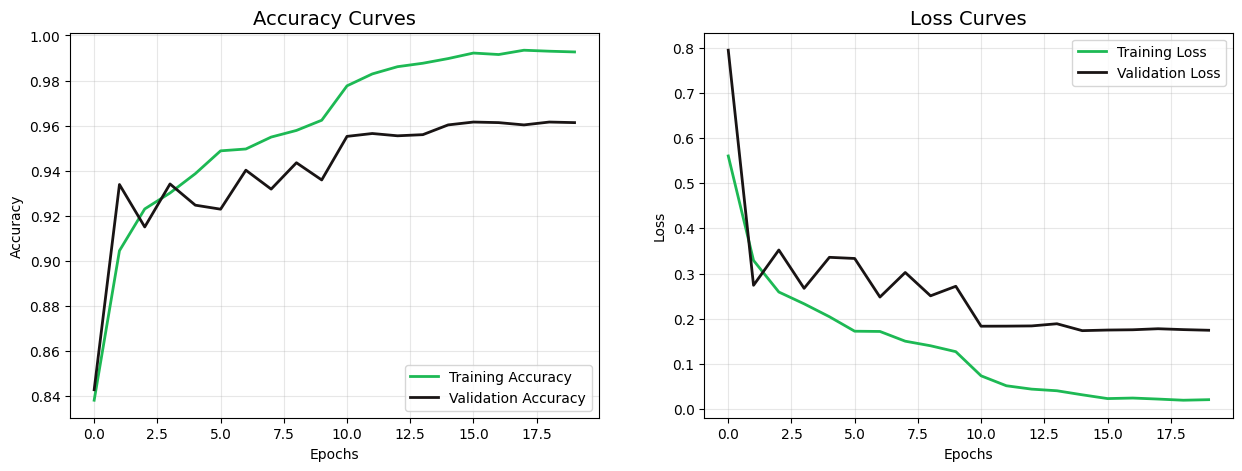

In [27]:
acc = model_history['accuracy']
val_acc = model_history['val_accuracy']
loss = model_history['loss']
val_loss = model_history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1DB954', lw=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#191414', lw=2)
plt.title('Accuracy Curves', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#1DB954', lw=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#191414', lw=2)
plt.title('Loss Curves', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.show()
